# Phase 5 — Neural Network (Final Model)
Competition: Playground Series S6E7 — Predicting Student Health Risk  
Metric: **Balanced accuracy**  
Model: Keras MLP — 3-class softmax + class_weight compensation

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from src.data_prep import load_data, split_data, get_column_types
from src.features import load_preprocessor
from src.train import train_neural_net
from src.evaluate import evaluate_keras, plot_confusion_matrix, plot_training_history

## 1. Load data + fitted preprocessor (already saved in notebook 02)

In [2]:
train_df, test_df = load_data('../data/raw')
X_train, X_val, y_train, y_val = split_data(train_df)

# Load preprocessor fitted in notebook 02 — never re-fit
preprocessor = load_preprocessor('../models/preprocessor.pkl')
X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

print('X_train_proc shape:', X_train_proc.shape)

X_train_proc shape: (1600, 19)


## 2. Train neural network

In [3]:
nn, le, history = train_neural_net(
    X_train_proc, y_train,
    X_val_proc,   y_val,
    epochs=50, batch_size=32,
    save_path='../models/model_nn.h5'
)

# Save label encoder — needed for decoding predictions
joblib.dump(le, '../models/label_encoder.pkl')
print('Label classes:', le.classes_)

Epoch 1/50


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:17 2s/step - accuracy: 0.2500 - loss: 1.1393

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4076 - loss: 1.0766 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4435 - loss: 1.0432

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4481 - loss: 1.0371 - val_accuracy: 0.5400 - val_loss: 0.9388


...

Epoch 19/50


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5938 - loss: 0.8659

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6514 - loss: 0.7042 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6619 - loss: 0.6964 - val_accuracy: 0.6325 - val_loss: 0.7803


Neural net saved -> ../models/model_nn.h5
Label classes: ['at-risk' 'fit' 'unhealthy']


## 3. Evaluate with balanced accuracy (not Keras accuracy)

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step



-- Neural Net MLP --
Balanced accuracy: 0.6221
              precision    recall  f1-score   support

     at-risk       0.70      0.70      0.70       115
         fit       0.67      0.71      0.69       148
   unhealthy       0.49      0.45      0.47       137

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



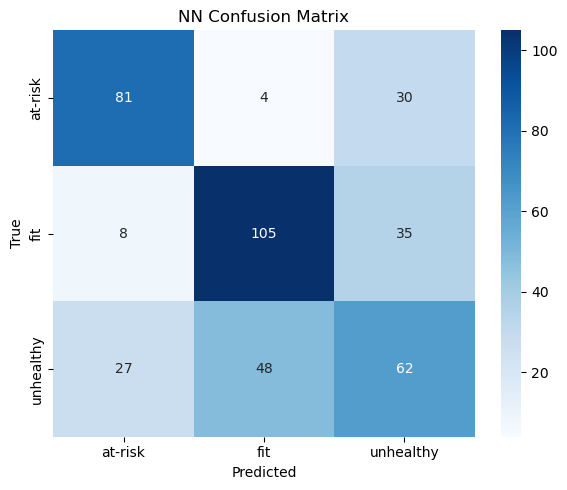

In [4]:
y_val_enc = le.transform(y_val)
nn_bal_acc, nn_preds_enc = evaluate_keras(nn, le, X_val_proc, y_val_enc, 'Neural Net MLP')
plot_confusion_matrix(y_val_enc, nn_preds_enc, le.classes_, title='NN Confusion Matrix')

## 4. Training curves

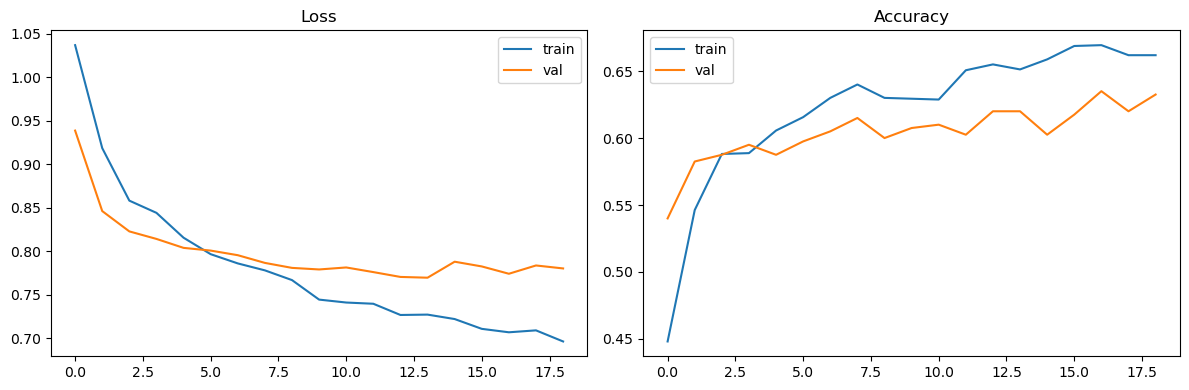

In [5]:
plot_training_history(history)

## 5. Compare all models — pick the winner

In [6]:
import pandas as pd

prev = pd.read_csv('../models/results_so_far.csv')
nn_row = pd.DataFrame([{
    'Model': 'Neural Net (MLP, class-weighted)',
    'Val balanced_acc': nn_bal_acc,
    'CV mean': '-',
    'CV std': '-',
    'Notes': f'{len(history.history["loss"])} epochs, early stopping'
}])

all_results = pd.concat([prev, nn_row], ignore_index=True)
print(all_results.to_markdown(index=False))
all_results.to_csv('../experiments.md', index=False)  # also saved below as proper md

| Model                            |   Val balanced_acc | CV mean   | CV std   | Notes                                                                                                                                                                                                                                                                                                                                                                                                                               |
|:---------------------------------|-------------------:|:----------|:---------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# Write experiments.md in the format specified by the docs
with open('../experiments.md', 'w') as f:
    f.write('| Model | Val balanced accuracy | CV mean ± std | Notes |\n')
    f.write('|---|---|---|---|\n')
    for _, row in all_results.iterrows():
        cv = f"{row['CV mean']} ± {row['CV std']}" if row['CV mean'] != '-' else '-'
        f.write(f"| {row['Model']} | {row['Val balanced_acc']} | {cv} | {row['Notes']} |\n")
print('experiments.md written.')

experiments.md written.


## 6. Promote best model to model_final

> **Decision:** Compare `nn_bal_acc` vs the RF balanced accuracy from notebook 02.  
> Copy the winning artifact to `models/model_final.*` and update `src/predict.py` accordingly.

In [8]:
import shutil

# Change 'nn' to 'rf' if RF won
winner = 'nn'   # <-- set this after comparing

if winner == 'nn':
    shutil.copy('../models/model_nn.h5', '../models/model_final.h5')
    print('Winner: Neural Net — model_final.h5 is the submission model.')
    print('Use predict_keras() in src/predict.py to generate submission.')
else:
    print('Winner: Random Forest — model_final.pkl already set in notebook 02.')
    print('Use predict_sklearn() in src/predict.py to generate submission.')

Winner: Neural Net — model_final.h5 is the submission model.
Use predict_keras() in src/predict.py to generate submission.
